# MWTek Cowboy Shootout — Statistical Analysis

This notebook analyzes games produced by the Java program and answers: **is the game fair, who is most likely to win, and how long does a game take?** Python only analyzes the CSV files; it does not reimplement the game.

## Terms to know

| Term | Plain-language meaning |
| --- | --- |
| Cowboy ID | Permanent label such as Cowboy 0 or Cowboy 3 |
| Starter | Cowboy who fires the first shot in that game |
| Offset | Winner's position measured from the starter; offset 0 is the starter |
| Normalized offset | `offset / N`; increasing values follow each inward-facing cowboy's own `LEFT` direction |
| Fixed starter | Every simulated game starts with the same cowboy |
| Random starter | Each game chooses its starter randomly |

## Data sources

The Java application produces two kinds of output:

- A normal run writes the detailed JSON protocol and its SHA-256 checksum.
- A batch run writes one compact CSV row per completed game.

This notebook analyzes the batch CSV files. `fixed-starter-n5.csv` is the primary dataset, `random-starter-n5.csv` is the random-starter control, and the remaining `fixed-starter-n*.csv` files provide the scale comparison. Local execution can regenerate these datasets when the configuration switches are enabled; browser execution analyzes uploaded files only.

In [1]:
from pathlib import Path
import sys

IN_BROWSER = sys.platform == 'emscripten'

def find_project_root(starting_directory):
    starting_directory = starting_directory.resolve()
    for candidate in (starting_directory, *starting_directory.parents):
        if (candidate / 'pom.xml').exists():
            return candidate
    return None

PROJECT_ROOT = None if IN_BROWSER else find_project_root(Path.cwd())
if not IN_BROWSER and PROJECT_ROOT is None:
    raise FileNotFoundError('Open this notebook from the project root or its analysis directory.')

mode = 'JupyterLite / Pyodide' if IN_BROWSER else 'local project'
print(f'Execution mode: {mode}')

Execution mode: local project


In [2]:
# JupyterLite starts with a small Python environment, so install analysis packages there.
if IN_BROWSER:
    import micropip
    await micropip.install(['numpy', 'pandas', 'scipy', 'matplotlib'])
    print('Browser analysis packages are ready.')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import PercentFormatter
from IPython.display import display
from scipy.stats import chisquare, norm

COWBOY_COUNT_AXIS_LABEL = 'Number of cowboys'
ANNOTATION_COORDINATE_SYSTEM = 'offset points'

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')

if not IN_BROWSER:
    import subprocess

## Experiment configuration

This cell controls data generation; it does not change the rules of the game.

- `COWBOY_COUNT`: number of cowboys in the primary experiment.
- `SIMULATIONS`: number of complete games represented in the generated CSV.
- `MASTER_SEED`: makes the generated batch reproducible.
- `FIXED_STARTER = 0`: forces Cowboy 0 to start so relative positions can be compared.
- `REGENERATE_PRIMARY_DATA = True`: rebuilds and **overwrites** `fixed-starter-n5.csv` locally.
- `GENERATE_SCALE_DATA = True`: rebuilds and overwrites every configured `fixed-starter-n*.csv` locally.

With both generation switches set to `False`, the notebook uses the saved results. Browser mode always analyzes uploaded files and never runs Java.

In [4]:
COWBOY_COUNT = 5
SIMULATIONS = 10_000
MASTER_SEED = 123456
FIXED_STARTER = 0
REGENERATE_PRIMARY_DATA = False
GENERATE_SCALE_DATA = False
SCALE_COWBOY_COUNTS = [2, 3, 5, 10, 20, 50, 100, 200]

DATA_DIRECTORY = Path('.') if IN_BROWSER else PROJECT_ROOT / 'analysis' / 'output'
PRIMARY_CSV = DATA_DIRECTORY / 'fixed-starter-n5.csv'
RANDOM_STARTER_CSV = DATA_DIRECTORY / 'random-starter-n5.csv'
primary_csv_display = PRIMARY_CSV if IN_BROWSER else PRIMARY_CSV.relative_to(PROJECT_ROOT)
print(f'Primary dataset: {primary_csv_display}')

Primary dataset: analysis/output/fixed-starter-n5.csv


In [5]:
def run_java_batch(cowboy_count, simulations, output_path, fixed_starter=None):
    jar_path = PROJECT_ROOT / 'target' / 'cowboy-shootout-1.0.0.jar'
    command = [
        'java', '-jar', str(jar_path), str(cowboy_count),
        '--batch', str(simulations), '--seed', str(MASTER_SEED),
        '--summary', str(output_path),
    ]
    if fixed_starter is not None:
        command.extend(['--starter', str(fixed_starter)])
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)

if not IN_BROWSER and (REGENERATE_PRIMARY_DATA or GENERATE_SCALE_DATA):
    subprocess.run(['mvn', 'package', '-DskipTests'], cwd=PROJECT_ROOT, check=True)

if not IN_BROWSER and REGENERATE_PRIMARY_DATA:
    run_java_batch(COWBOY_COUNT, SIMULATIONS, PRIMARY_CSV, FIXED_STARTER)

if not IN_BROWSER and GENERATE_SCALE_DATA:
    for cowboy_count in SCALE_COWBOY_COUNTS:
        scale_path = DATA_DIRECTORY / f'fixed-starter-n{cowboy_count}.csv'
        run_java_batch(cowboy_count, SIMULATIONS, scale_path, FIXED_STARTER)

print('Existing CSV files will be analyzed.' if not REGENERATE_PRIMARY_DATA else 'Primary data regenerated.')

Existing CSV files will be analyzed.


## Load and validate the Java output

Validation rejects empty files, missing columns, and datasets that mix different cowboy counts. The preview shows the starter, seed, winner, game length, and winner statistics for the first five games.

In [6]:
REQUIRED_COLUMNS = {
    'simulationId', 'cowboyCount', 'seed', 'starterId', 'winnerId',
    'winnerOffsetFromStarter', 'totalShots', 'winnerRemainingHp',
    'winnerShotsFired', 'winnerKills', 'winnerTotalDamageDealt',
}

def load_summary(csv_path):
    if not csv_path.exists():
        available_files = sorted(path.name for path in DATA_DIRECTORY.glob('*.csv'))
        raise FileNotFoundError(
            f'{csv_path.name} was not found next to the notebook. '
            f'Available CSV files: {available_files}'
        )
    frame = pd.read_csv(csv_path)
    missing_columns = REQUIRED_COLUMNS.difference(frame.columns)
    if missing_columns:
        raise ValueError(f'{csv_path.name} is missing columns: {sorted(missing_columns)}')
    if frame.empty:
        raise ValueError(f'{csv_path.name} contains no simulations.')
    if frame['cowboyCount'].nunique() != 1:
        raise ValueError(f'{csv_path.name} mixes different cowboy counts.')
    return frame

games = load_summary(PRIMARY_CSV)
print(f'Loaded {len(games):,} games with {int(games.cowboyCount.iloc[0])} cowboys.')
display(games.head())

Loaded 10,000 games with 5 cowboys.


,simulationId,cowboyCount,seed,starterId,winnerId,winnerOffsetFromStarter,totalShots,winnerRemainingHp,winnerShotsFired,winnerKills,winnerTotalDamageDealt
0,1,5,7622549244507814510,0,3,3,17,1,5,3,11
1,2,5,-176823638348867382,0,0,0,17,1,7,2,20
2,3,5,4653291594555506559,0,2,2,18,1,3,1,6
3,4,5,-5429547764223392703,0,2,2,16,7,3,2,7
4,5,5,1354699720820100286,0,3,3,19,4,4,2,9


## Statistical measures


| Measure | Purpose | Interpretation |
| --- | --- | --- |
| Observed probability | How often did this position win? | `0.27` means 27 wins per 100 games |
| Equal probability | What would equal chances look like? | For 5 cowboys the reference is `1/5 = 0.20` |
| 95% confidence interval | How precise is the observed rate? | A narrow interval means less sampling uncertainty |
| Chi-square p-value | Is the complete shape hard to reconcile with equal probabilities? | A small value is evidence against exact equality; it is not the size of the advantage |
| Cohen's w | How large is the overall departure from equality? | Larger values mean a stronger overall difference |
| Pearson residual | Which position contributes to that difference? | Positive = more wins than expected; negative = fewer |

The same functions calculate these measures throughout the notebook.

In [7]:
def wilson_intervals(win_counts, sample_size, confidence=0.95):
    z_score = norm.ppf(1 - (1 - confidence) / 2)
    probabilities = win_counts / sample_size
    denominator = 1 + z_score**2 / sample_size
    centers = (probabilities + z_score**2 / (2 * sample_size)) / denominator
    half_widths = (
        z_score
        * np.sqrt((probabilities * (1 - probabilities) + z_score**2 / (4 * sample_size)) / sample_size)
        / denominator
    )
    return centers - half_widths, centers + half_widths

def analyze_winner_distribution(frame, position_column):
    cowboy_count = int(frame['cowboyCount'].iloc[0])
    positions = np.arange(cowboy_count)
    win_counts = frame[position_column].value_counts().reindex(positions, fill_value=0).sort_index()
    sample_size = len(frame)
    expected_count = sample_size / cowboy_count
    chi_square, p_value = chisquare(win_counts, np.full(cowboy_count, expected_count))
    probabilities = win_counts / sample_size
    ci_low, ci_high = wilson_intervals(win_counts, sample_size)
    equal_probability = 1 / cowboy_count

    distribution = pd.DataFrame({
        'position': positions,
        'wins': win_counts.to_numpy(),
        'probability': probabilities.to_numpy(),
        'ci95Low': np.asarray(ci_low),
        'ci95High': np.asarray(ci_high),
        'differenceFromEqual': probabilities.to_numpy() - equal_probability,
        'relativeLiftFromEqual': probabilities.to_numpy() / equal_probability - 1,
        'pearsonResidual': (win_counts.to_numpy() - expected_count) / np.sqrt(expected_count),
    })
    metrics = {
        'games': sample_size,
        'cowboys': cowboy_count,
        'equalProbability': equal_probability,
        'chiSquare': chi_square,
        'degreesOfFreedom': cowboy_count - 1,
        'pValue': p_value,
        'cohensW': np.sqrt(chi_square / sample_size),
        'largestAbsoluteProbabilityGap': distribution['differenceFromEqual'].abs().max(),
    }
    return distribution, metrics

## 1. Does position matter when the starter is fixed?

Cowboy 0 starts every game. This analysis experiment freezes the circle to compare seats around the starter. Offset 0 is the starter; offsets 1–4 are the other seats. In the Java circle, IDs increase toward `LEFT`: for five cowboys, offset `+1` is the starter's first LEFT neighbor and offset `+4` (`N - 1`) is the first RIGHT neighbor.

The left panel compares each position with the dashed `20%` equal-chance line. The right panel shows each position's contribution to the difference: positive bars indicate more wins than expected and negative bars indicate fewer.

**Result:** offset `+2` — two seats or `40%` toward `LEFT` from the inward-facing starter (`60%` toward `RIGHT`) — won most often (`27.4%`). Offset `+4` — `80%` toward `LEFT`, equivalently the first neighbor or `20%` toward `RIGHT` — won least often (`8.1%`). Therefore the relative positions are not equally favorable for five cowboys. This does not mean that permanent Cowboy 2 is always strongest.

In [8]:
fixed_starter = games['starterId'].nunique() == 1
position_column = 'winnerOffsetFromStarter' if fixed_starter else 'winnerId'
winner_distribution, winner_metrics = analyze_winner_distribution(games, position_column)
most_likely_position = winner_distribution.loc[winner_distribution['probability'].idxmax()]
least_likely_position = winner_distribution.loc[winner_distribution['probability'].idxmin()]

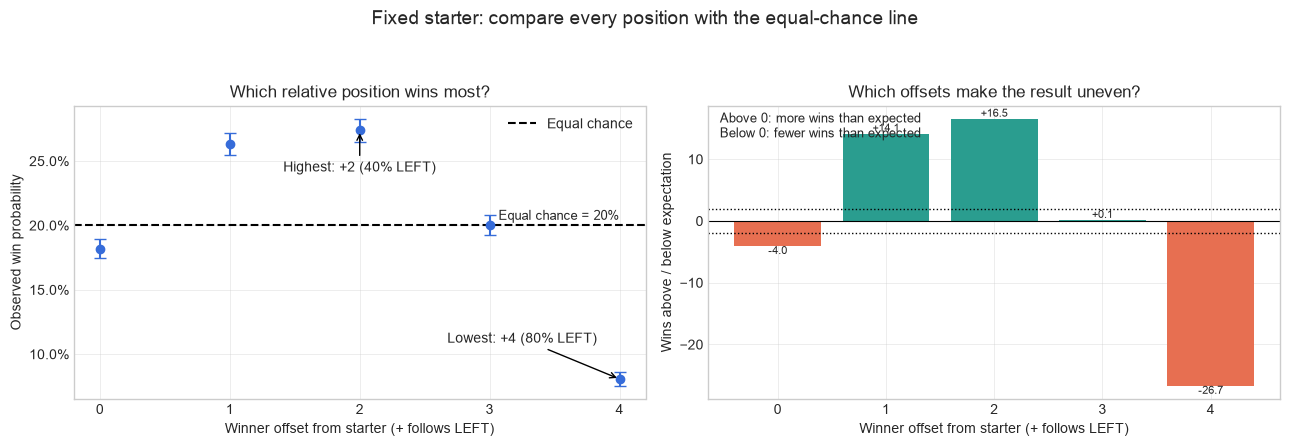

In [9]:
positions = winner_distribution['position'].to_numpy()
number_of_positions = int(games['cowboyCount'].iloc[0])
probabilities = winner_distribution['probability'].to_numpy()
lower_error = probabilities - winner_distribution['ci95Low'].to_numpy()
upper_error = winner_distribution['ci95High'].to_numpy() - probabilities

figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].errorbar(positions, probabilities, yerr=[lower_error, upper_error], fmt='o', capsize=4)
axes[0].axhline(winner_metrics['equalProbability'], color='black', linestyle='--', label='Equal chance')
axes[0].text(
    positions.max(), winner_metrics['equalProbability'] + 0.002,
    f"Equal chance = {100 * winner_metrics['equalProbability']:.0f}%",
    ha='right', va='bottom', fontsize=9,
)
axes[0].set(title='Which relative position wins most?', xlabel='Winner offset from starter (+ follows LEFT)', ylabel='Observed win probability')
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].annotate(
    f"Highest: +{int(most_likely_position['position'])} "
    f"({100 * most_likely_position['position'] / number_of_positions:.0f}% LEFT)",
    xy=(most_likely_position['position'], most_likely_position['probability']),
    xytext=(0, -22), textcoords=ANNOTATION_COORDINATE_SYSTEM, ha='center', va='top',
    arrowprops={'arrowstyle': '->'},
)
axes[0].annotate(
    f"Lowest: +{int(least_likely_position['position'])} "
    f"({100 * least_likely_position['position'] / number_of_positions:.0f}% LEFT)",
    xy=(least_likely_position['position'], least_likely_position['probability']),
    xytext=(-16, 24), textcoords=ANNOTATION_COORDINATE_SYSTEM, ha='right', va='bottom',
    arrowprops={'arrowstyle': '->'},
)
axes[0].legend()

residual_colors = np.where(winner_distribution['pearsonResidual'] >= 0, '#2a9d8f', '#e76f51')
axes[1].bar(positions, winner_distribution['pearsonResidual'], color=residual_colors)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axhline(2, color='black', linestyle=':', linewidth=1)
axes[1].axhline(-2, color='black', linestyle=':', linewidth=1)
axes[1].set(title='Which offsets make the result uneven?', xlabel='Winner offset from starter (+ follows LEFT)', ylabel='Wins above / below expectation')
axes[1].text(
    0.02, 0.98, 'Above 0: more wins than expected\nBelow 0: fewer wins than expected',
    transform=axes[1].transAxes, va='top', fontsize=9,
)
for bar, residual in zip(axes[1].patches, winner_distribution['pearsonResidual']):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, residual, f'{residual:+.1f}',
        ha='center', va='bottom' if residual >= 0 else 'top', fontsize=8,
    )
for axis in axes:
    if len(positions) <= 30:
        axis.set_xticks(positions)
figure.suptitle('Fixed starter: compare every position with the equal-chance line', fontsize=14)
figure.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## 2. Identity fairness and position fairness

### Fixed starter

Cowboy 0 starts **every game**. This experiment answers: **which seat around a known starter is more likely to win?** It does not test whether the permanent name `Cowboy 0` is naturally lucky.

### Random starter

A new starter is randomly selected in **every game**, as required by the normal game rules. This tests whether a permanent ID such as Cowboy 0 wins more often overall.

### Why the same game can be viewed in two ways

With five cowboys:

```text
Game A: starter = Cowboy 0, winner = Cowboy 2  -> offset +2 = 40% toward LEFT
Game B: starter = Cowboy 3, winner = Cowboy 0  -> offset +2 = 40% toward LEFT
```

The winners have different permanent IDs, but both occupied the same seat: `40%` around the circle toward the inward-facing starter's `LEFT` (`60%` toward `RIGHT`). This is why the notebook examines both **ID** and **offset**.

### Three-panel comparison

1. **Fixed starter / relative position:** Cowboy 0 always starts; the uneven bars show a position effect.
2. **Random starter / permanent ID:** the nearly equal bars show no clear permanent-ID effect.
3. **Random starter / relative position:** grouping by position makes the position effect visible again.

The advantageous **seat** remains, while random starter selection rotates different **cowboy IDs** through that seat.

,p-value,Cohen's w,largest gap (percentage points),plain-language result
comparison,,,,
Fixed starter / position,<0.001,0.3460,11.9300,Uneven: evidence of a difference
Random starter / permanent ID,0.761,0.0140,0.5100,Approximately flat: no clear difference
Random starter / position,<0.001,0.3290,11.4300,Uneven: evidence of a difference


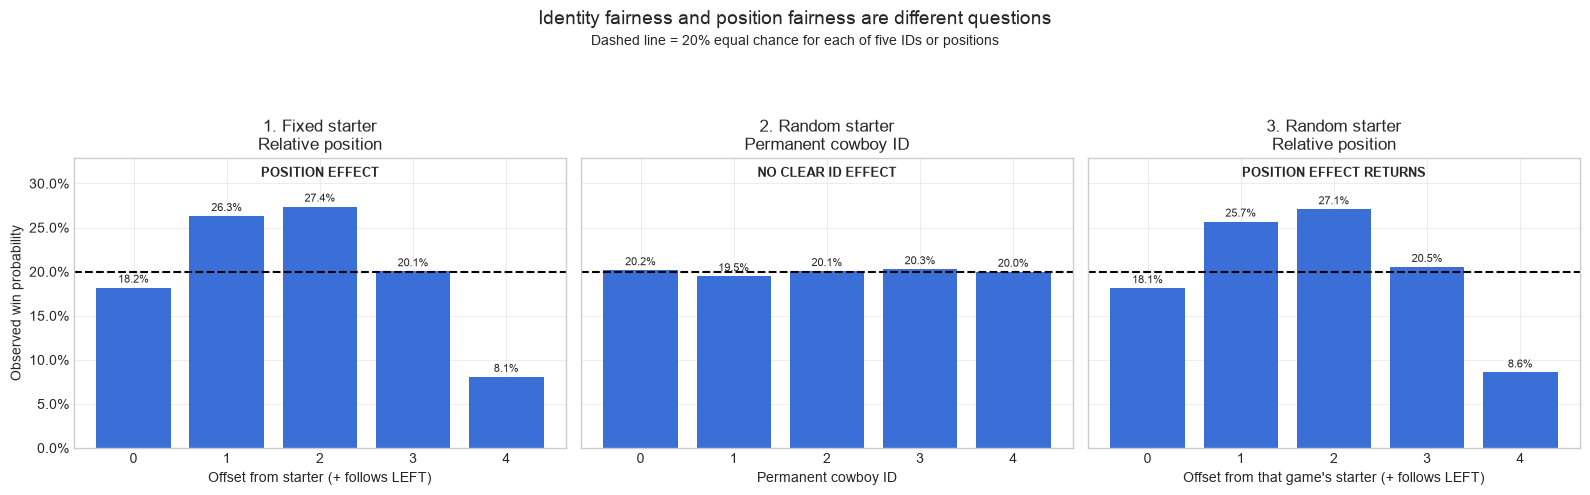

In [10]:
if RANDOM_STARTER_CSV.exists():
    random_games = load_summary(RANDOM_STARTER_CSV)
    random_absolute, random_absolute_metrics = analyze_winner_distribution(random_games, 'winnerId')
    random_relative, random_relative_metrics = analyze_winner_distribution(random_games, 'winnerOffsetFromStarter')

    comparison_specs = [
        ('Fixed starter / position', winner_metrics, 'Do starter-relative positions differ?'),
        ('Random starter / permanent ID', random_absolute_metrics, 'Are permanent cowboy IDs different?'),
        ('Random starter / position', random_relative_metrics, 'Does relative position still matter?'),
    ]
    fairness_comparison = pd.DataFrame([
        {
            'comparison': label,
            'p-value': '<0.001' if metrics['pValue'] < 0.001 else f"{metrics['pValue']:.3f}",
            "Cohen's w": metrics['cohensW'],
            'largest gap (percentage points)': 100 * metrics['largestAbsoluteProbabilityGap'],
            'plain-language result': (
                'Uneven: evidence of a difference'
                if metrics['pValue'] < 0.05
                else 'Approximately flat: no clear difference'
            ),
        }
        for label, metrics, question in comparison_specs
    ]).set_index('comparison')
    display(fairness_comparison.round({
        "Cohen's w": 3,
        'largest gap (percentage points)': 2,
    }))
    figure, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
    panels = [
        ('1. Fixed starter\nRelative position', 'Offset from starter (+ follows LEFT)',
         winner_distribution, winner_metrics, 'POSITION EFFECT'),
        ('2. Random starter\nPermanent cowboy ID', 'Permanent cowboy ID',
         random_absolute, random_absolute_metrics, 'NO CLEAR ID EFFECT'),
        ('3. Random starter\nRelative position', 'Offset from that game\'s starter (+ follows LEFT)',
         random_relative, random_relative_metrics, 'POSITION EFFECT RETURNS'),
    ]
    largest_panel_probability = max(
        distribution['probability'].max() for _, _, distribution, _, _ in panels
    )
    for axis, (title, x_label, distribution, metrics, result_label) in zip(axes, panels):
        bars = axis.bar(distribution['position'], distribution['probability'], color='#3b6fd8')
        axis.axhline(
            metrics['equalProbability'], color='black', linestyle='--', linewidth=1.5,
        )
        for bar, probability in zip(bars, distribution['probability']):
            axis.text(
                bar.get_x() + bar.get_width() / 2, probability + 0.003,
                f'{100 * probability:.1f}%', ha='center', va='bottom', fontsize=8,
            )
        axis.set(title=title, xlabel=x_label)
        axis.set_xticks(distribution['position'])
        axis.set_ylim(0, largest_panel_probability + 0.055)
        axis.yaxis.set_major_formatter(PercentFormatter(1.0))
        axis.text(
            0.5, 0.97, result_label, transform=axis.transAxes,
            ha='center', va='top', fontweight='bold', fontsize=9,
        )
    axes[0].set_ylabel('Observed win probability')
    figure.suptitle(
        'Identity fairness and position fairness are different questions', fontsize=14,
    )
    figure.text(
        0.5, 0.91, 'Dashed line = 20% equal chance for each of five IDs or positions',
        ha='center', fontsize=10,
    )
    figure.tight_layout(rect=[0, 0, 1, 0.86])
    plt.show()
else:
    print(f'Optional control file not found: {RANDOM_STARTER_CSV.name}. Upload it to enable this section.')

## 3. How long does a game take?

The histogram shows the distribution of game lengths; the smooth curve is only a visual comparison. The cumulative chart shows the percentage of games completed by each shot count.

**Result for five cowboys:** the average is `17.33` shots, and about `95%` of games finish by `21` shots. The longest observed game used `27` shots; the strict mathematical ceiling is `49`.

### Winner-statistics heatmap

The diagonal `1.00` cells are self-correlations and are excluded from interpretation. Among the other cells, values near `+1` rise together, values near `−1` move in opposite directions, and values near `0` have little linear relationship.

**Result:** winner shots and winner damage have the strongest relationship (`0.82`). This is a relationship, not proof that one causes the other.

,mean shots,median,middle 90%,observed maximum,strict maximum
0,17.3300,17,14–21,27,49


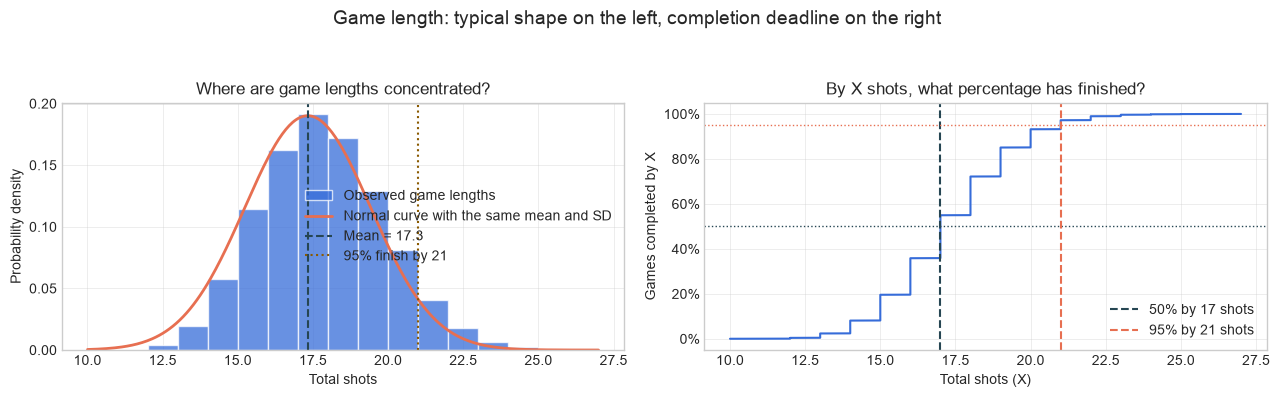

In [11]:
game_lengths = games['totalShots']
cowboy_count = int(games['cowboyCount'].iloc[0])
mean_standard_error = game_lengths.std(ddof=1) / np.sqrt(len(game_lengths))
mean_margin = norm.ppf(0.975) * mean_standard_error
length_summary = pd.Series({
    'games': len(game_lengths),
    'meanShots': game_lengths.mean(),
    'meanCi95Low': game_lengths.mean() - mean_margin,
    'meanCi95High': game_lengths.mean() + mean_margin,
    'standardDeviation': game_lengths.std(ddof=1),
    'median': game_lengths.median(),
    'p05': game_lengths.quantile(0.05),
    'p95': game_lengths.quantile(0.95),
    'observedMaximum': game_lengths.max(),
    'theoreticalMaximum': 10 * cowboy_count - 1,
    'meanShotsPerCowboy': game_lengths.mean() / cowboy_count,
})
game_length_summary = pd.DataFrame([{
    'mean shots': round(game_lengths.mean(), 2),
    'median': int(game_lengths.median()),
    'middle 90%': f"{game_lengths.quantile(0.05):.0f}–{game_lengths.quantile(0.95):.0f}",
    'observed maximum': int(game_lengths.max()),
    'strict maximum': 10 * cowboy_count - 1,
}])
display(game_length_summary)

normal_x = np.linspace(game_lengths.min(), game_lengths.max(), 300)
normal_density = norm.pdf(normal_x, game_lengths.mean(), game_lengths.std(ddof=1))

figure, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(
    game_lengths, bins='auto', density=True, alpha=0.75, edgecolor='white',
    label='Observed game lengths',
)
axes[0].plot(
    normal_x, normal_density, color='#e76f51', linewidth=2,
    label='Normal curve with the same mean and SD',
)
axes[0].axvline(
    game_lengths.mean(), color='#264653', linestyle='--',
    label=f"Mean = {game_lengths.mean():.1f}",
)
axes[0].axvline(
    game_lengths.quantile(0.95), color='#8a5a00', linestyle=':',
    label=f"95% finish by {game_lengths.quantile(0.95):.0f}",
)
axes[0].set(
    title='Where are game lengths concentrated?',
    xlabel='Total shots', ylabel='Probability density',
)
axes[0].legend()

sorted_lengths = np.sort(game_lengths.to_numpy())
cumulative_probability = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths)
axes[1].plot(sorted_lengths, cumulative_probability)
axes[1].set(title='By X shots, what percentage has finished?', xlabel='Total shots (X)', ylabel='Games completed by X')
median_shots = game_lengths.median()
p95_shots = game_lengths.quantile(0.95)
axes[1].axhline(0.50, color='#264653', linestyle=':', linewidth=1)
axes[1].axvline(median_shots, color='#264653', linestyle='--', label=f'50% by {median_shots:.0f} shots')
axes[1].axhline(0.95, color='#e76f51', linestyle=':', linewidth=1)
axes[1].axvline(p95_shots, color='#e76f51', linestyle='--', label=f'95% by {p95_shots:.0f} shots')
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].legend()
figure.suptitle('Game length: typical shape on the left, completion deadline on the right', fontsize=14)
figure.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

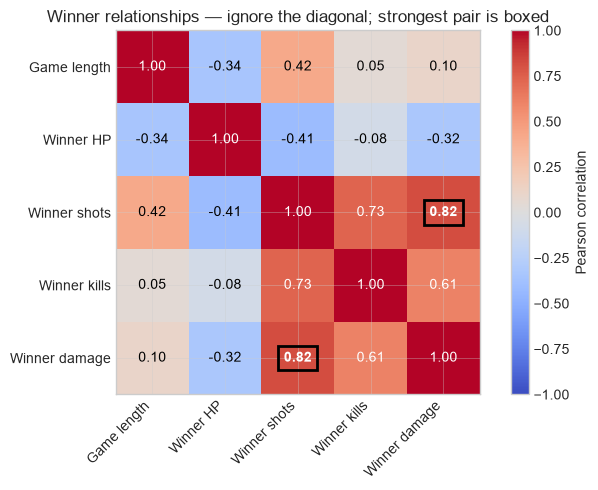

In [12]:
performance_columns = [
    'totalShots', 'winnerRemainingHp', 'winnerShotsFired',
    'winnerKills', 'winnerTotalDamageDealt',
]
correlations = games[performance_columns].corr(method='pearson')
upper_triangle = correlations.where(
    np.triu(np.ones(correlations.shape), k=1).astype(bool)
)
correlation_pairs = upper_triangle.stack()
strongest_pair = correlation_pairs.abs().idxmax()
strongest_value = correlations.loc[strongest_pair[0], strongest_pair[1]]
readable_performance_labels = [
    'Game length', 'Winner HP', 'Winner shots', 'Winner kills', 'Winner damage',
]
figure, axis = plt.subplots(figsize=(7, 5))
image = axis.imshow(correlations, vmin=-1, vmax=1, cmap='coolwarm')
axis.set_xticks(range(len(performance_columns)), readable_performance_labels, rotation=45, ha='right')
axis.set_yticks(range(len(performance_columns)), readable_performance_labels)
strongest_pair_indexes = {
    (performance_columns.index(strongest_pair[0]), performance_columns.index(strongest_pair[1])),
    (performance_columns.index(strongest_pair[1]), performance_columns.index(strongest_pair[0])),
}
for row in range(len(performance_columns)):
    for column in range(len(performance_columns)):
        correlation_value = correlations.iloc[row, column]
        is_strongest_pair = (row, column) in strongest_pair_indexes
        axis.text(
            column, row, f'{correlation_value:.2f}', ha='center', va='center',
            color='white' if abs(correlation_value) > 0.55 else 'black',
            fontweight='bold' if is_strongest_pair else 'normal',
            bbox=(
                {'facecolor': 'none', 'edgecolor': 'black', 'linewidth': 2}
                if is_strongest_pair else None
            ),
        )
figure.colorbar(image, ax=axis, label='Pearson correlation')
axis.set_title('Winner relationships — ignore the diagonal; strongest pair is boxed')
figure.tight_layout()
plt.show()

## 4. What changes when the number of cowboys grows?

Each tested size uses 10,000 games. The three panels summarize:

1. **Total shots:** grows from about `5.9` at `N=2` to `754` at `N=200`.
2. **Shots per cowboy:** approaches about `3.77`, so average game length grows roughly in proportion to the cowboy count.
3. **Starter win rate:** the dashed line is the equal-chance reference. Starting helps in very small circles but becomes a disadvantage as the circle grows.

### Regional heatmap

Each row is a cowboy count and each column is one fifth of the circle measured from the starter. The horizontal scale is `normalized offset = offset / N`. Because every cowboy faces inward, increasing offset follows that cowboy's own `LEFT` direction, not the viewer's screen-left direction:

- `1.00×` = equal expectation
- above `1.00×` = winners appear more often in that region
- below `1.00×` = winners appear less often

```text
Starter -- about 69–70% toward LEFT --> winner
Starter -- about 30–31% toward RIGHT -> the same winner
```

**Result:** as the number of cowboys increases, winners become more concentrated in the `60–80%` LEFT-directed region from the starter. At `N=200`, this region contains `75.1%` of the winners instead of the `20%` expected if all five regions were equal. In other words, winners appear in this region `3.76×` as often as the equal baseline predicts. The same region is `20–40%` around the circle toward `RIGHT`. This is an advantage of a position relative to the starter, not an advantage of a permanent Cowboy ID.

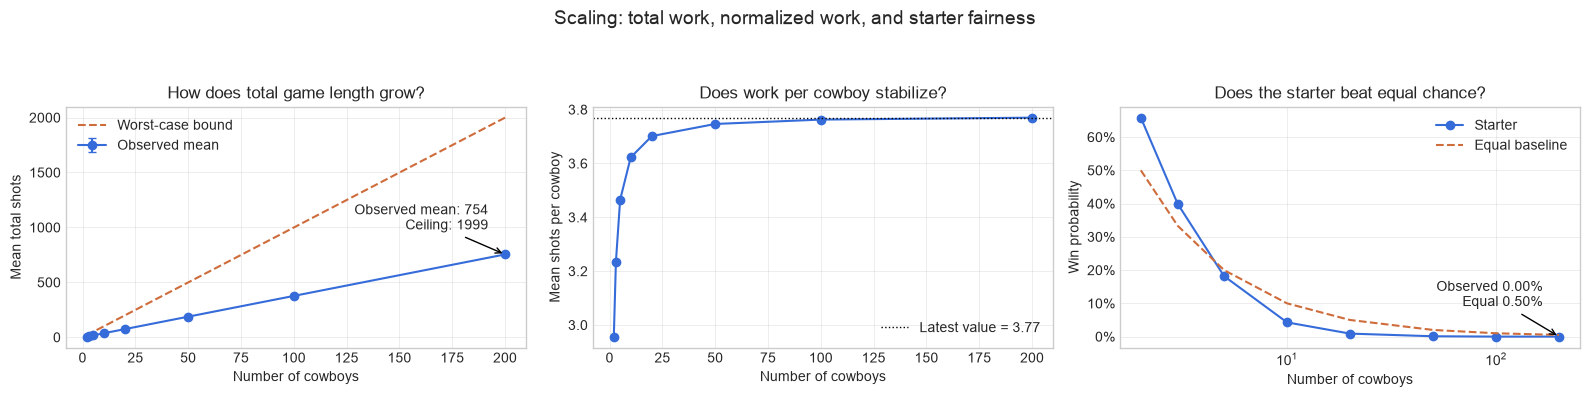

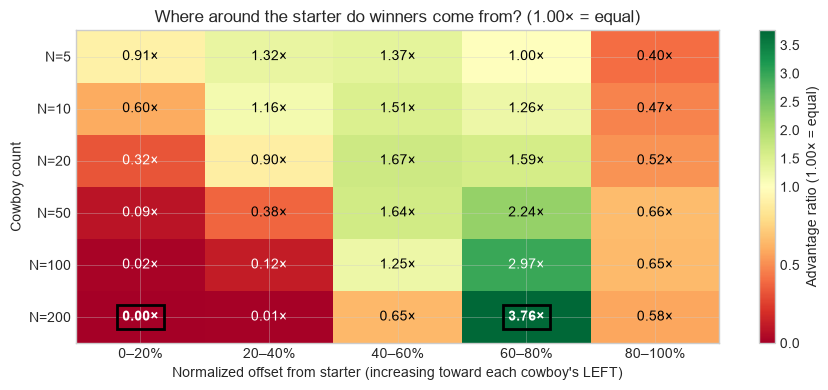

In [13]:
def summarize_scale_file(csv_path):
    frame = load_summary(csv_path)
    cowboy_count = int(frame['cowboyCount'].iloc[0])
    distribution, metrics = analyze_winner_distribution(frame, 'winnerOffsetFromStarter')
    mean_shots = frame['totalShots'].mean()
    mean_margin = norm.ppf(0.975) * frame['totalShots'].std(ddof=1) / np.sqrt(len(frame))
    starter_probability = distribution.loc[distribution['position'] == 0, 'probability'].iloc[0]
    return {
        'cowboyCount': cowboy_count,
        'simulations': len(frame),
        'meanShots': mean_shots,
        'meanShotsCi95Low': mean_shots - mean_margin,
        'meanShotsCi95High': mean_shots + mean_margin,
        'meanShotsPerCowboy': mean_shots / cowboy_count,
        'medianShots': frame['totalShots'].median(),
        'p95Shots': frame['totalShots'].quantile(0.95),
        'observedMaximum': frame['totalShots'].max(),
        'theoreticalMaximum': 10 * cowboy_count - 1,
        'starterWinProbability': starter_probability,
        'equalProbability': 1 / cowboy_count,
        'largestWinProbability': distribution['probability'].max(),
        'uniformityPValue': metrics['pValue'],
        'cohensW': metrics['cohensW'],
    }

scale_paths = sorted(
    DATA_DIRECTORY.glob('fixed-starter-n*.csv'),
    key=lambda path: int(path.stem.split('-n')[-1]),
)

if len(scale_paths) >= 2:
    scale_summary = pd.DataFrame(summarize_scale_file(path) for path in scale_paths).sort_values('cowboyCount')
    smallest_scale = scale_summary.iloc[0]
    largest_scale = scale_summary.iloc[-1]
    figure, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].errorbar(
        scale_summary['cowboyCount'], scale_summary['meanShots'],
        yerr=[
            scale_summary['meanShots'] - scale_summary['meanShotsCi95Low'],
            scale_summary['meanShotsCi95High'] - scale_summary['meanShots'],
        ],
        marker='o', capsize=3, label='Observed mean',
    )
    axes[0].plot(scale_summary['cowboyCount'], scale_summary['theoreticalMaximum'], linestyle='--', label='Worst-case bound')
    axes[0].set(title='How does total game length grow?', xlabel=COWBOY_COUNT_AXIS_LABEL, ylabel='Mean total shots')
    axes[0].annotate(
        f"Observed mean: {largest_scale['meanShots']:.0f}\nCeiling: {largest_scale['theoreticalMaximum']:.0f}",
        xy=(largest_scale['cowboyCount'], largest_scale['meanShots']),
        xytext=(-12, 18), textcoords=ANNOTATION_COORDINATE_SYSTEM, ha='right',
        arrowprops={'arrowstyle': '->'},
    )
    axes[0].legend()

    axes[1].plot(scale_summary['cowboyCount'], scale_summary['meanShotsPerCowboy'], marker='o')
    axes[1].axhline(
        largest_scale['meanShotsPerCowboy'], color='black', linestyle=':', linewidth=1,
        label=f"Latest value = {largest_scale['meanShotsPerCowboy']:.2f}",
    )
    axes[1].set(title='Does work per cowboy stabilize?', xlabel=COWBOY_COUNT_AXIS_LABEL, ylabel='Mean shots per cowboy')
    axes[1].legend()

    axes[2].plot(scale_summary['cowboyCount'], scale_summary['starterWinProbability'], marker='o', label='Starter')
    axes[2].plot(scale_summary['cowboyCount'], scale_summary['equalProbability'], linestyle='--', label='Equal baseline')
    axes[2].set(title='Does the starter beat equal chance?', xlabel=COWBOY_COUNT_AXIS_LABEL, ylabel='Win probability', xscale='log')
    axes[2].yaxis.set_major_formatter(PercentFormatter(1.0))
    axes[2].annotate(
        f"Observed {100 * largest_scale['starterWinProbability']:.2f}%\nEqual {100 * largest_scale['equalProbability']:.2f}%",
        xy=(largest_scale['cowboyCount'], largest_scale['starterWinProbability']),
        xytext=(-12, 22), textcoords=ANNOTATION_COORDINATE_SYSTEM, ha='right',
        arrowprops={'arrowstyle': '->'},
    )
    axes[2].legend()
    figure.suptitle('Scaling: total work, normalized work, and starter fairness', fontsize=14)
    figure.tight_layout(rect=[0, 0, 1, 0.91])
    plt.show()

    # Compare equivalent parts of differently sized circles. Each column is one fifth of the circle.
    advantage_rows = []
    advantage_index = []
    for scale_path in scale_paths:
        scale_games = load_summary(scale_path)
        scale_cowboy_count = int(scale_games['cowboyCount'].iloc[0])
        if scale_cowboy_count < 5 or scale_cowboy_count % 5 != 0:
            continue

        region_number = np.minimum(
            scale_games['winnerOffsetFromStarter'].to_numpy() * 5 // scale_cowboy_count,
            4,
        )
        region_probability = (
            pd.Series(region_number)
            .value_counts(normalize=True)
            .reindex(range(5), fill_value=0)
            .sort_index()
        )
        advantage_rows.append((region_probability / 0.20).to_numpy())
        advantage_index.append(scale_cowboy_count)

    advantage_heatmap = pd.DataFrame(
        advantage_rows,
        index=[f'N={cowboy_count}' for cowboy_count in advantage_index],
        columns=['0–20%', '20–40%', '40–60%', '60–80%', '80–100%'],
    )
    strongest_region = np.unravel_index(
        np.argmax(advantage_heatmap.to_numpy()), advantage_heatmap.shape,
    )
    weakest_region = np.unravel_index(
        np.argmin(advantage_heatmap.to_numpy()), advantage_heatmap.shape,
    )
    strongest_ratio = advantage_heatmap.iloc[strongest_region]
    weakest_ratio = advantage_heatmap.iloc[weakest_region]
    figure, axis = plt.subplots(figsize=(9, max(4, len(advantage_heatmap) * 0.65)))
    heatmap_upper_limit = max(2.0, float(advantage_heatmap.to_numpy().max()))
    heatmap_colors = TwoSlopeNorm(vmin=0, vcenter=1, vmax=heatmap_upper_limit)
    heatmap_image = axis.imshow(
        advantage_heatmap, aspect='auto', cmap='RdYlGn', norm=heatmap_colors,
    )
    axis.set_xticks(range(5), advantage_heatmap.columns)
    axis.set_yticks(range(len(advantage_heatmap)), advantage_heatmap.index)
    axis.set_xlabel('Normalized offset from starter (increasing toward each cowboy\'s LEFT)')
    axis.set_ylabel('Cowboy count')
    axis.set_title('Where around the starter do winners come from? (1.00× = equal)')
    for row_number in range(len(advantage_heatmap)):
        for column_number in range(5):
            advantage_ratio = advantage_heatmap.iloc[row_number, column_number]
            is_strongest = (row_number, column_number) == strongest_region
            is_weakest = (row_number, column_number) == weakest_region
            axis.text(
                column_number, row_number, f'{advantage_ratio:.2f}×',
                ha='center', va='center',
                color='white' if advantage_ratio < 0.35 or advantage_ratio > 2.4 else 'black',
                fontweight='bold' if is_strongest or is_weakest else 'normal',
                bbox=(
                    {'facecolor': 'none', 'edgecolor': 'black', 'linewidth': 2}
                    if is_strongest or is_weakest else None
                ),
            )
    figure.colorbar(heatmap_image, ax=axis, label='Advantage ratio (1.00× = equal)')
    figure.tight_layout()
    plt.show()
else:
    scale_summary = None
    print('Upload at least two fixed-starter-n*.csv files to enable the scale comparison.')

## 5. Is 10,000 simulations enough?

The table shows three representative circle sizes. The final column indicates whether 10,000 games meet the selected precision target:

- `True`: 10,000 games meet this notebook's precision target for one exact position.
- `False`: more games are required for a precise claim about one exact position.

**Result:** 10,000 games are sufficient for the selected target at `N=5` and `N=20`, but not at `N=200`. The large-circle heatmap can still show broad regions, but an observed zero for one exact position does not prove that its real probability is zero.

In [14]:
TARGET_RELATIVE_MARGIN = 0.20
z_score = norm.ppf(0.975)
precision_rows = []
for cowboy_count in SCALE_COWBOY_COUNTS:
    baseline_probability = 1 / cowboy_count
    target_absolute_margin = TARGET_RELATIVE_MARGIN * baseline_probability
    approximate_games = int(np.ceil(
        z_score**2 * baseline_probability * (1 - baseline_probability) / target_absolute_margin**2
    ))
    observed_half_width_at_10k = z_score * np.sqrt(
        baseline_probability * (1 - baseline_probability) / 10_000
    )
    precision_rows.append({
        'cowboyCount': cowboy_count,
        'uniformBaseline': baseline_probability,
        'targetAbsoluteHalfWidth': target_absolute_margin,
        'approximateGamesRequired': approximate_games,
        'absoluteHalfWidthAt10k': observed_half_width_at_10k,
        'relativeHalfWidthAt10k': observed_half_width_at_10k / baseline_probability,
        'tenThousandMeetsTarget': (
            observed_half_width_at_10k / baseline_probability <= TARGET_RELATIVE_MARGIN
        ),
    })
precision_table = pd.DataFrame(precision_rows)
precision_summary = precision_table.loc[
    precision_table['cowboyCount'].isin([5, 20, 200]),
    ['cowboyCount', 'approximateGamesRequired', 'relativeHalfWidthAt10k', 'tenThousandMeetsTarget'],
].copy()
precision_summary['relativeHalfWidthAt10k'] = precision_summary['relativeHalfWidthAt10k'].map(
    lambda value: f'{100 * value:.1f}%'
)
precision_summary = precision_summary.rename(columns={
    'cowboyCount': 'cowboys',
    'approximateGamesRequired': 'games needed',
    'relativeHalfWidthAt10k': 'uncertainty at 10,000 games',
    'tenThousandMeetsTarget': '10,000 is enough',
})
display(precision_summary)

,cowboys,games needed,"uncertainty at 10,000 games","10,000 is enough"
2,5,385,3.9%,True
4,20,1825,8.5%,True
7,200,19112,27.6%,False


## Conclusion

A **Cowboy ID** identifies a person; an **offset** identifies that person's position relative to the starter. IDs increase toward `LEFT`, so offset `+1` is the first LEFT neighbor and offset `N - 1` is the first RIGHT neighbor. Random starter selection changes which Cowboy ID occupies each relative position:

```text
                  +0     +1     +2     +3     +4
Starter = C0  ->  C0     C1     C2     C3     C4
Starter = C3  ->  C3     C4     C0     C1     C2
Starter = C1  ->  C1     C2     C3     C4     C0
                                ^
          a different ID occupies offset +2 = 40% toward LEFT
```

### **Five-cowboy result: offset +2 (40% toward LEFT) was the most successful position**

In the five-cowboy fixed-starter experiment, offset `+2` — two seats or `40%` around the circle toward the inward-facing starter's `LEFT` (`60%` toward `RIGHT`) — won about `27.4%`. This is a positional result, not a permanent advantage for Cowboy 2: a different Cowboy ID occupies that LEFT-directed position whenever the starter changes.

### Summary of results

- **Identity fairness:** because the starter is selected randomly, no permanent Cowboy ID keeps the positional advantage. Each ID has overall probability `1/N`.
- **Position fairness:** after the starter is known, relative positions are not equally favorable.
- **Game length:** with five cowboys, games average `17.33` shots and about `95%` finish by `21` shots.
- **Larger circles:** average game length grows roughly with the cowboy count. At `N=200`, winners concentrate in the `60–80%` LEFT-directed region, centered near normalized offset `0.69–0.70`; the same location is about `30–31%` toward `RIGHT`.

For a single game, the Java console reports the same position as `offset +k/N` and in both directions. For example, `offset +2/5` means `40%` toward `LEFT`, or equivalently `60%` toward `RIGHT`. These are directions from the inward-facing cowboy's perspective. This is the same `winnerOffsetFromStarter` measure used by the CSV tables and charts.